# Atelier Matplotlib — IoT

Une entreprise possède plusieurs bâtiments équipés de capteurs IoT. Chaque capteur collecte
régulièrement des informations sur la température, l'humidité, la pression, la consommation
énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure.

Après NumPy et Pandas, on représente ici graphiquement les informations avec Matplotlib pour
identifier des tendances, des différences entre bâtiments et des anomalies.


## Installation et import des bibliothèques

Matplotlib et Pandas sont installés, puis importés.


In [1]:
# Installation (une seule fois)
# %pip install matplotlib pandas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Affichage des graphiques directement dans le notebook
%matplotlib inline
print("pandas :", pd.__version__)
print("matplotlib :", plt.matplotlib.__version__)

pandas : 2.3.3
matplotlib : 3.10.7+dfsg1


## Chargement des données

In [3]:
df = pd.read_csv("../data/mesures_capteurs.csv", parse_dates=["date_heure"])
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_mesure     605 non-null    object        
 1   date_heure    605 non-null    datetime64[ns]
 2   id_capteur    605 non-null    object        
 3   batiment      605 non-null    object        
 4   temperature   599 non-null    float64       
 5   humidite      600 non-null    float64       
 6   pression      600 non-null    float64       
 7   consommation  600 non-null    float64       
 8   etat          601 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 42.7+ KB


In [5]:
df.describe()

,date_heure,temperature,humidite,pression,consommation
count,605,599.000000,600.00000,600.000000,600.000000
mean,2026-01-17 11:32:43.636363776,24.878314,64.92620,1012.221900,208.675417
min,2026-01-05 00:00:00,-18.500000,28.52000,850.000000,18.120000
25%,2026-01-11 05:00:00,22.570000,58.17250,1006.790000,160.177500
50%,2026-01-17 12:00:00,24.860000,65.37500,1012.855000,206.150000
75%,2026-01-23 18:00:00,27.275000,71.61500,1017.827500,254.127500
max,2026-01-29 23:00:00,58.700000,145.00000,1038.430000,875.000000
std,NaN,4.059576,10.76905,10.599042,72.243567


In [6]:
print("Lignes :", len(df))
print("Colonnes :", list(df.columns))
print("Valeurs manquantes par colonne :")
df.isna().sum()


Lignes : 605
Colonnes : ['id_mesure', 'date_heure', 'id_capteur', 'batiment', 'temperature', 'humidite', 'pression', 'consommation', 'etat']
Valeurs manquantes par colonne :


id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     6
humidite        5
pression        5
consommation    5
etat            4
dtype: int64

### Nettoyage

On supprime les lignes sans température (nécessaire pour la Partie 1) et on trie par date.

In [7]:
df_clean = df.dropna(subset=["temperature"]).sort_values("date_heure").reset_index(drop=True)
print("Lignes conservées :", len(df_clean))

Lignes conservées : 599


# Partie 1 – Graphique linéaire (Line Plot)

Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende
et la grille.

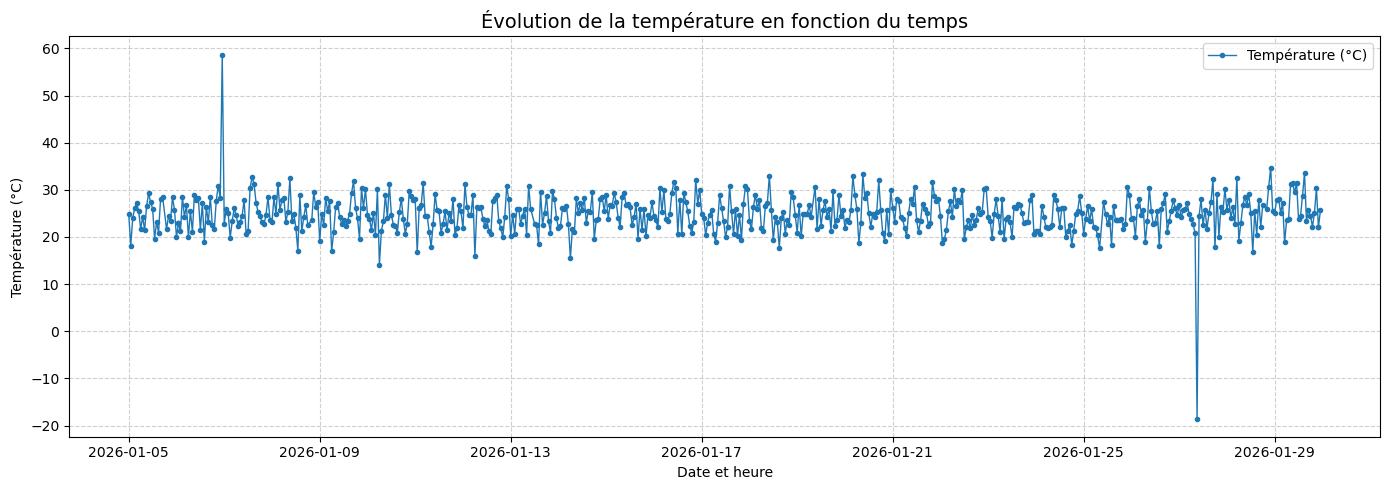

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_clean["date_heure"],
    df_clean["temperature"],
    marker="o",
    markersize=3,
    linewidth=1,
    color="tab:blue",
    label="Température (°C)",
)

ax.set_title("Évolution de la température en fonction du temps", fontsize=14)
ax.set_xlabel("Date et heure")
ax.set_ylabel("Température (°C)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

### 2) Identification visuelle des anomalies

La majorité des températures se situe entre 15 °C et 35 °C environ. On observe clairement
un point isolé et très élevé autour de 58,7 °C, mesuré le 2026-01-06 à 23:00 dans le
bâtiment B004. Cette valeur est fortement éloignée du reste de la série : c'est une valeur
aberrante (probablement un capteur défaillant).

In [9]:
# Repérer le point aberrant le plus extrême
extremes = df_clean.nlargest(3, "temperature")[["date_heure", "batiment", "id_capteur", "temperature"]]
extremes

,date_heure,batiment,id_capteur,temperature
47,2026-01-06 23:00:00,B004,C012,58.70
572,2026-01-28 22:00:00,B004,C011,34.72
589,2026-01-29 15:00:00,B002,C004,33.60


In [10]:
# Aperçu du même bâtiment pour confirmer l'anomalie
df_clean[df_clean["batiment"] == "B004"]["temperature"].describe()

count    150.000000
mean      27.119000
std        5.367361
min      -18.500000
25%       25.175000
50%       27.535000
75%       29.282500
max       58.700000
Name: temperature, dtype: float64